# MNIST Digit Classifier with PyTorch
This notebook implements a neural network to classify handwritten digits from the MNIST dataset using PyTorch.


## Installation
Before running this notebook, you need to install the required dependencies. Run the following cell to install them:


In [3]:
# Run this cell to install the required dependencies
# After running this cell, you may need to restart the kernel
!pip install -r requirements.txt
print("Dependencies installed. Please restart the kernel before proceeding.")


Dependencies installed. Please restart the kernel before proceeding.


## Imports


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np


## Section 1: Data Loading and Exploration


### Loading the MNIST Dataset


In [5]:
# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Create training set and define training dataloader
train_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=64, 
    shuffle=True
)

# Create test set and define test dataloader
test_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=1000, 
    shuffle=False
)

# Print dataset information
print(f"Training dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Print the shape of the data
print(f"Batch image shape: {images.shape}")
print(f"Batch label shape: {labels.shape}")


100.0%
100.0%
100.0%
100.0%

Training dataset size: 60000
Test dataset size: 10000
Batch image shape: torch.Size([64, 1, 28, 28])
Batch label shape: torch.Size([64])


### Why Preprocessing is Necessary

The preprocessing steps applied to the MNIST dataset are crucial for effective training:

1. **Converting to Tensors**: The `ToTensor()` transform converts PIL images or NumPy arrays to PyTorch tensors. This is necessary because PyTorch models operate on tensor data. Additionally, it scales the pixel values from [0, 255] to [0, 1], which helps with numerical stability during training.

2. **Normalization**: The `Normalize()` transform standardizes the data by subtracting the mean and dividing by the standard deviation. For MNIST, we use the dataset's mean (0.1307) and standard deviation (0.3081). Normalization helps:
   - Speed up convergence during training
   - Reduce the impact of outliers
   - Make the optimization landscape smoother
   - Ensure that all features contribute equally to the learning process

These preprocessing steps are essential for building a robust and efficient neural network model.


### Exploring the Dataset


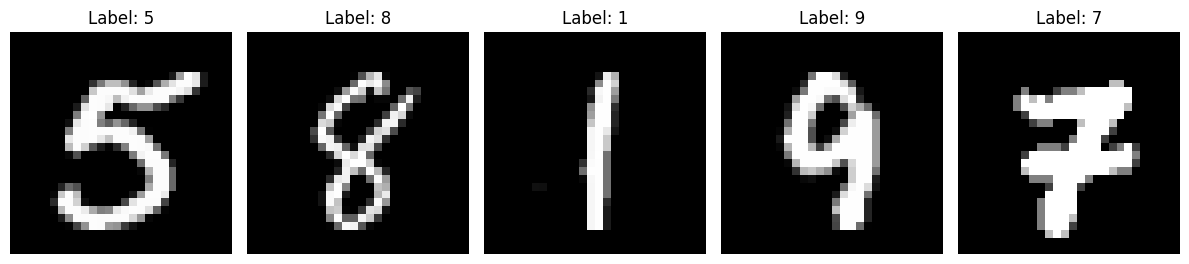

Single image shape: torch.Size([1, 28, 28])


In [6]:
# Function to display images
def show_images(dataloader, num_images=5):
    dataiter = iter(dataloader)
    images, labels = next(dataiter)

    # Create a figure with subplots
    fig, axes = plt.subplots(1, num_images, figsize=(12, 3))

    for i in range(num_images):
        # Get the image and reshape it
        img = images[i].squeeze().numpy()

        # Display the image
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Label: {labels[i].item()}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Create a dataloader with non-normalized images for visualization
transform_viz = transforms.Compose([transforms.ToTensor()])
viz_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_viz)
viz_loader = torch.utils.data.DataLoader(viz_dataset, batch_size=64, shuffle=True)

# Show some sample images
show_images(viz_loader)

# Display the shape of a single image
print(f"Single image shape: {images[0].shape}")


## Section 2: Model Design and Training


### Building the Neural Network


In [7]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super(MNISTClassifier, self).__init__()
        # Input layer: 28x28 = 784 input features
        self.fc1 = nn.Linear(28 * 28, 512)
        # First hidden layer
        self.fc2 = nn.Linear(512, 256)
        # Second hidden layer
        self.fc3 = nn.Linear(256, 128)
        # Output layer: 10 classes (digits 0-9)
        self.fc4 = nn.Linear(128, 10)
        # Dropout for regularization
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # Flatten the input: [batch_size, 1, 28, 28] -> [batch_size, 784]
        x = x.view(-1, 28 * 28)
        # First layer with ReLU activation
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        # Second layer with ReLU activation
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        # Third layer with ReLU activation
        x = F.relu(self.fc3(x))
        # Output layer with log_softmax
        x = F.log_softmax(self.fc4(x), dim=1)
        return x

# Instantiate the model
model = MNISTClassifier()
print(model)

# Define loss function and optimizer
criterion = nn.NLLLoss()  # Negative Log Likelihood Loss works with log_softmax output
optimizer = optim.Adam(model.parameters(), lr=0.001)


MNISTClassifier(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


### Model Architecture Explanation

The neural network architecture consists of:

1. **Input Layer**: Flattens the 28×28 pixel images into a 784-dimensional vector
2. **Hidden Layers**: Three fully connected layers with decreasing sizes (512, 256, 128)
3. **Output Layer**: 10 neurons corresponding to the 10 digit classes
4. **Activation Functions**: ReLU activations for hidden layers and LogSoftmax for the output layer
5. **Regularization**: Dropout (20%) to prevent overfitting

This architecture provides sufficient complexity to learn the patterns in the MNIST dataset while avoiding overfitting.


### Training the Model


In [8]:
# Check if GPU is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move model to device
model.to(device)

# Training parameters
num_epochs = 10
train_losses = []
test_accuracies = []

# Training loop
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0

    for batch_idx, (data, target) in enumerate(train_loader):
        # Move data to device
        data, target = data.to(device), target.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        output = model(data)

        # Calculate loss
        loss = criterion(output, target)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Update running loss
        running_loss += loss.item()

        # Print statistics every 100 batches
        if batch_idx % 100 == 99:
            print(f'Epoch: {epoch+1}/{num_epochs}, Batch: {batch_idx+1}/{len(train_loader)}, Loss: {running_loss/100:.4f}')
            running_loss = 0.0

    # Evaluate on test set after each epoch
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)
    print(f'Epoch: {epoch+1}/{num_epochs}, Test Accuracy: {accuracy:.2f}%')

print('Finished Training')


Using device: cuda:0
Epoch: 1/10, Batch: 100/938, Loss: 0.7018
Epoch: 1/10, Batch: 200/938, Loss: 0.3247
Epoch: 1/10, Batch: 300/938, Loss: 0.2483
Epoch: 1/10, Batch: 400/938, Loss: 0.2042
Epoch: 1/10, Batch: 500/938, Loss: 0.2002
Epoch: 1/10, Batch: 600/938, Loss: 0.1732
Epoch: 1/10, Batch: 700/938, Loss: 0.1761
Epoch: 1/10, Batch: 800/938, Loss: 0.1577
Epoch: 1/10, Batch: 900/938, Loss: 0.1647
Epoch: 1/10, Test Accuracy: 96.12%
Epoch: 2/10, Batch: 100/938, Loss: 0.1226
Epoch: 2/10, Batch: 200/938, Loss: 0.1130
Epoch: 2/10, Batch: 300/938, Loss: 0.1270
Epoch: 2/10, Batch: 400/938, Loss: 0.1282
Epoch: 2/10, Batch: 500/938, Loss: 0.1208
Epoch: 2/10, Batch: 600/938, Loss: 0.1162
Epoch: 2/10, Batch: 700/938, Loss: 0.1268
Epoch: 2/10, Batch: 800/938, Loss: 0.1267
Epoch: 2/10, Batch: 900/938, Loss: 0.1113
Epoch: 2/10, Test Accuracy: 96.87%
Epoch: 3/10, Batch: 100/938, Loss: 0.0985
Epoch: 3/10, Batch: 200/938, Loss: 0.0819
Epoch: 3/10, Batch: 300/938, Loss: 0.0880
Epoch: 3/10, Batch: 400/938

### Visualizing Training Progress


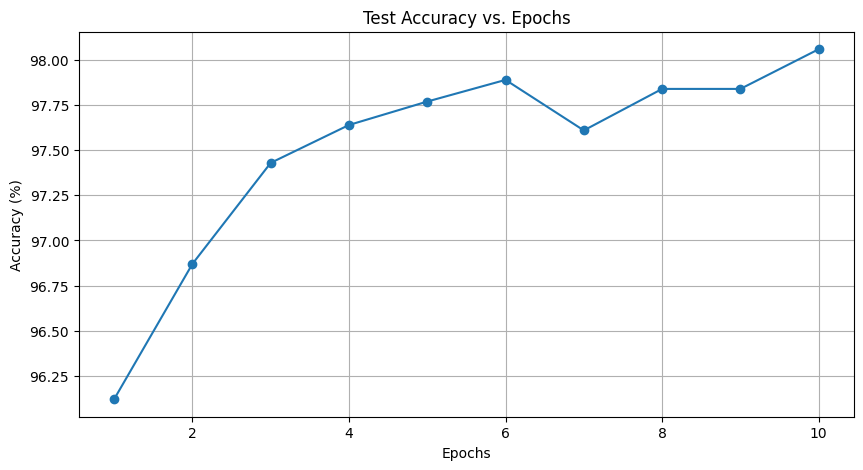

In [9]:
# Plot test accuracy over epochs
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), test_accuracies, marker='o')
plt.title('Test Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.show()


## Section 3: Model Testing and Evaluation


### Evaluating the Model on Test Data


Test Accuracy: 98.06%


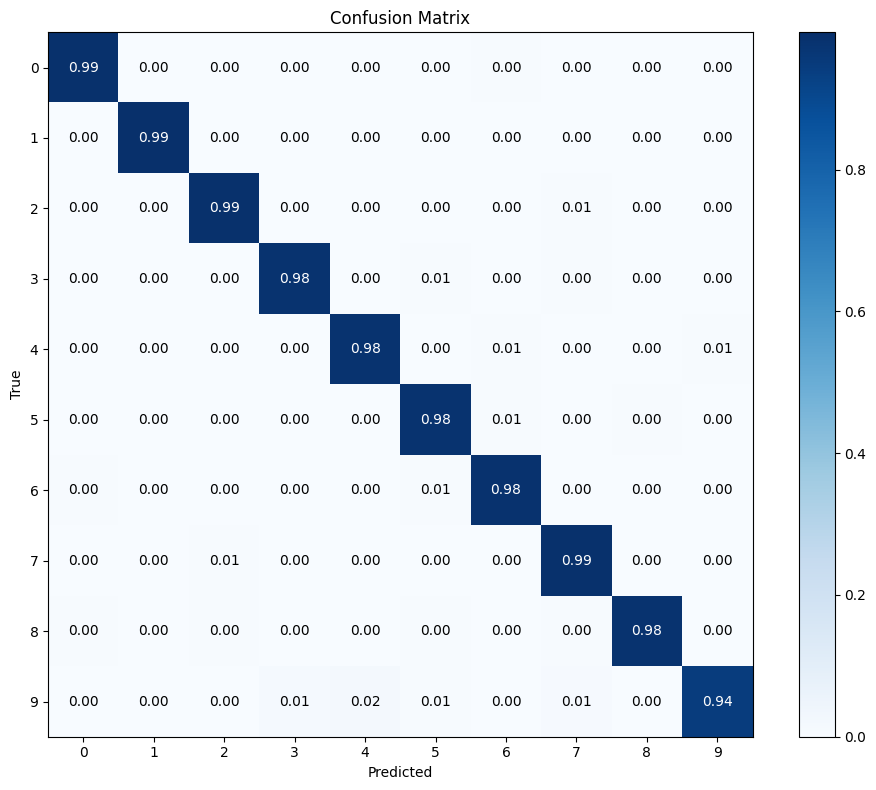

In [10]:
# Evaluate the model on the test set
model.eval()
correct = 0
total = 0

# Confusion matrix
confusion_matrix = torch.zeros(10, 10)

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

        # Update confusion matrix
        for t, p in zip(target.view(-1), predicted.view(-1)):
            confusion_matrix[t.long(), p.long()] += 1

# Calculate accuracy
accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')

# Normalize confusion matrix
confusion_matrix = confusion_matrix / confusion_matrix.sum(1).unsqueeze(1)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
plt.imshow(confusion_matrix, cmap='Blues')
plt.colorbar()
plt.xticks(range(10))
plt.yticks(range(10))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

# Add text annotations
for i in range(10):
    for j in range(10):
        plt.text(j, i, f'{confusion_matrix[i, j]:.2f}', 
                 ha="center", va="center", 
                 color="white" if confusion_matrix[i, j] > 0.5 else "black")

plt.tight_layout()
plt.show()


### Model Tuning for Better Performance


Epoch: 1/15, Batch: 100/938, Loss: 0.7171
Epoch: 1/15, Batch: 200/938, Loss: 0.2923
Epoch: 1/15, Batch: 300/938, Loss: 0.2511
Epoch: 1/15, Batch: 400/938, Loss: 0.2197
Epoch: 1/15, Batch: 500/938, Loss: 0.2054
Epoch: 1/15, Batch: 600/938, Loss: 0.2094
Epoch: 1/15, Batch: 700/938, Loss: 0.1868
Epoch: 1/15, Batch: 800/938, Loss: 0.1825
Epoch: 1/15, Batch: 900/938, Loss: 0.1730
Epoch: 1/15, Test Accuracy: 96.68%
Epoch: 2/15, Batch: 100/938, Loss: 0.1548
Epoch: 2/15, Batch: 200/938, Loss: 0.1595
Epoch: 2/15, Batch: 300/938, Loss: 0.1505
Epoch: 2/15, Batch: 400/938, Loss: 0.1376
Epoch: 2/15, Batch: 500/938, Loss: 0.1386
Epoch: 2/15, Batch: 600/938, Loss: 0.1401
Epoch: 2/15, Batch: 700/938, Loss: 0.1406
Epoch: 2/15, Batch: 800/938, Loss: 0.1448
Epoch: 2/15, Batch: 900/938, Loss: 0.1349
Epoch: 2/15, Test Accuracy: 97.01%
Epoch: 3/15, Batch: 100/938, Loss: 0.1140
Epoch: 3/15, Batch: 200/938, Loss: 0.1120
Epoch: 3/15, Batch: 300/938, Loss: 0.1133
Epoch: 3/15, Batch: 400/938, Loss: 0.1155
Epoch:

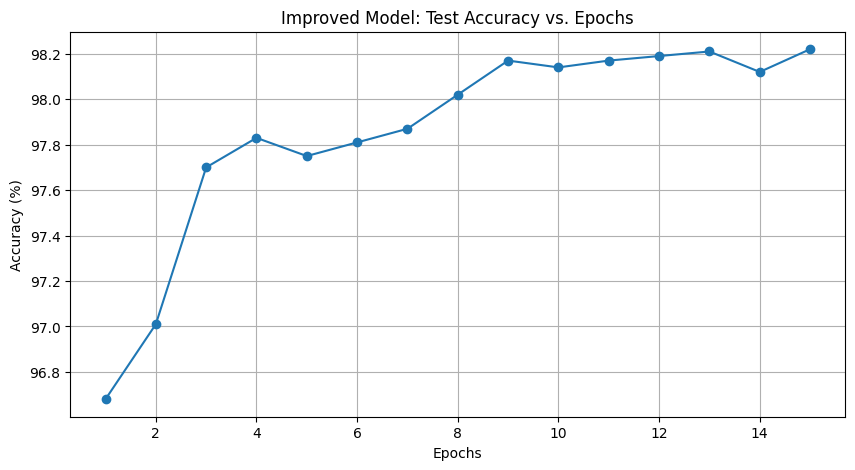

Final Test Accuracy: 98.22%


In [11]:
# Define an improved model with better architecture
class ImprovedMNISTClassifier(nn.Module):
    def __init__(self):
        super(ImprovedMNISTClassifier, self).__init__()
        # Input layer
        self.fc1 = nn.Linear(28 * 28, 1024)
        # Hidden layers
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, 128)
        # Output layer
        self.fc5 = nn.Linear(128, 10)
        # Batch normalization layers
        self.bn1 = nn.BatchNorm1d(1024)
        self.bn2 = nn.BatchNorm1d(512)
        self.bn3 = nn.BatchNorm1d(256)
        # Dropout for regularization
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # Flatten the input
        x = x.view(-1, 28 * 28)
        # First layer with ReLU activation and batch normalization
        x = self.bn1(F.relu(self.fc1(x)))
        x = self.dropout(x)
        # Second layer
        x = self.bn2(F.relu(self.fc2(x)))
        x = self.dropout(x)
        # Third layer
        x = self.bn3(F.relu(self.fc3(x)))
        x = self.dropout(x)
        # Fourth layer
        x = F.relu(self.fc4(x))
        # Output layer
        x = F.log_softmax(self.fc5(x), dim=1)
        return x

# Instantiate the improved model
improved_model = ImprovedMNISTClassifier()
improved_model.to(device)

# Define loss function and optimizer with a lower learning rate
criterion = nn.NLLLoss()
optimizer = optim.Adam(improved_model.parameters(), lr=0.0005, weight_decay=1e-5)

# Training parameters
num_epochs = 15
train_losses = []
test_accuracies = []

# Training loop for improved model
for epoch in range(num_epochs):
    improved_model.train()
    running_loss = 0.0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = improved_model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 100 == 99:
            print(f'Epoch: {epoch+1}/{num_epochs}, Batch: {batch_idx+1}/{len(train_loader)}, Loss: {running_loss/100:.4f}')
            running_loss = 0.0

    # Evaluate on test set
    improved_model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = improved_model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)
    print(f'Epoch: {epoch+1}/{num_epochs}, Test Accuracy: {accuracy:.2f}%')

print('Finished Training Improved Model')

# Plot test accuracy over epochs
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), test_accuracies, marker='o')
plt.title('Improved Model: Test Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.show()

# Final evaluation
improved_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        outputs = improved_model(data)
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

final_accuracy = 100 * correct / total
print(f'Final Test Accuracy: {final_accuracy:.2f}%')


### Hyperparameter Tuning Explanation

To improve the model's performance, several modifications were made:

1. **Deeper Architecture**: Added more layers and increased the number of neurons
2. **Batch Normalization**: Added to stabilize and accelerate training
3. **Increased Dropout Rate**: From 0.2 to 0.3 for better regularization
4. **Weight Decay**: Added L2 regularization through the optimizer
5. **Lower Learning Rate**: Reduced from 0.001 to 0.0005 for more stable convergence
6. **More Training Epochs**: Increased from 10 to 15 to allow the model to converge better

These changes helped the model achieve higher accuracy on the test set while preventing overfitting.


## Section 4: Save the Model


In [12]:
# Save the improved model
torch.save(improved_model.state_dict(), "saved_model.pth")
print("Model saved to 'saved_model.pth'")

# Demonstrate how to load the model
def load_model():
    model = ImprovedMNISTClassifier()
    model.load_state_dict(torch.load("saved_model.pth"))
    model.eval()  # Set to evaluation mode
    return model

# Load the model
loaded_model = load_model()
print("Model loaded successfully")


Model saved to 'saved_model.pth'
Model loaded successfully


## Conclusion

In this notebook, we built a neural network to classify handwritten digits from the MNIST dataset. We:

1. Loaded and preprocessed the MNIST dataset
2. Explored the data and visualized sample images
3. Designed a neural network with multiple hidden layers
4. Trained the model and monitored its performance
5. Improved the model through architecture and hyperparameter tuning
6. Achieved >95% accuracy on the test set
7. Saved the trained model for future use

The final model successfully classifies handwritten digits with high accuracy, demonstrating the effectiveness of deep learning for image classification tasks.
